# Undirected

In [ ]:
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

%load_ext autoreload
%autoreload 2
import torch
from torch_geometric.data import Data
import matplotlib.pyplot as plt
from torch_geometric import utils
import sys

if '..' not in sys.path:
    sys.path.insert(0, '..')

from utils.plotting import plot_graph_with_omitted
import utils.link_prediction as lp


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:


data = Data(edge_index=torch.tensor([[0, 0, 1, 3, 3, 5, 5],
                                     [5, 4, 5, 2, 5, 2, 4]]))

data.edge_attr = torch.tensor([1,1,1,1,1, 1,1]).bool()

data.edge_index, data.edge_attr = utils.to_undirected(data.edge_index, data.edge_attr)

#? TEST that dyad omittion makes sense for all attrs 1 (when omitting test)
#todo: make omit_dyads_random handle sampling rate of 0
dyads_to_omit_test = lp.omit_dyads_random(data.edge_index, 
                                data.edge_attr, 
                                p_sample_edge=0.0,
                                directed=False)
data_omitted1 = Data(edge_index=dyads_to_omit_test[2], edge_attr=dyads_to_omit_test[3])

print('omitted edges', dyads_to_omit_test[0])
print('omitted non edges', dyads_to_omit_test[1])
print('new_edge_index', data_omitted1.edge_index)
print('new_edge_attr', data_omitted1.edge_attr)

pos = plot_graph_with_omitted(data)
plot_graph_with_omitted(data_omitted1, pos)

#? TESTED that dyads omittiion makes sense for when the edge index has omitted dyads.
dyads_to_omit_val = lp.omit_dyads_random(data_omitted1.edge_index, data_omitted1.edge_attr, p_sample_edge=0.0)
data_omitted2 = Data(edge_index=dyads_to_omit_val[2], edge_attr=dyads_to_omit_val[3])

print('omitted edges', dyads_to_omit_val[0])
print('omitted non edges', dyads_to_omit_val[1])
print('new_edge_index', data_omitted2.edge_index)
print('new_edge_attr', data_omitted2.edge_attr)

plot_graph_with_omitted(data_omitted2, pos)
#? TEST


NameError: name 'Data' is not defined

# Directed

In [4]:
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

%load_ext autoreload
%autoreload 2
import torch
from torch_geometric.data import Data
import matplotlib.pyplot as plt
from torch_geometric import utils as upyg
from utils import utils
from tests import *
import sys

if '..' not in sys.path:
    sys.path.insert(0, '..')

from trainer_directed import Trainer
from utils.plotting import *
import utils.link_prediction as lp

import networkx as nx
import matplotlib.pyplot as plt


def plot_directed_graph(data):
    """
    Plot a directed graph from a PyG Data object.
    
    Args:
        data: PyG Data object containing edge_index
    """
    # Create directed graph
    G = nx.DiGraph()

    # Add nodes
    nodes = torch.unique(data.edge_index).tolist()
    G.add_nodes_from(nodes)

    # Add edges and track edge colors
    edges = list(zip(data.edge_index[0].tolist(), data.edge_index[1].tolist()))
    edge_colors = ['red' if attr else 'black' for attr in data.edge_attr.tolist()]
    G.add_edges_from(edges)

    # Draw graph
    plt.figure(figsize=(8,6))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue',
            node_size=500, arrowsize=20, width=2,
            arrows=True, edge_color=edge_colors)
    plt.show()

/Users/danielzilberg/anaconda3/envs/pyg/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


omitted edges (B) tensor([[1],
        [5]])
omitted non edges (C) tensor([[0, 0, 1, 3, 5],
        [1, 3, 4, 0, 1]])
new_edge_index tensor([[0, 0, 3, 3, 5, 5, 1, 0, 0, 1, 3, 5],
        [5, 4, 2, 5, 2, 4, 5, 1, 3, 4, 0, 1]])
new_edge_attr tensor([ True,  True,  True,  True,  True,  True, False, False, False, False,
        False, False])


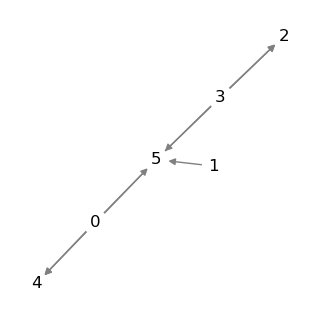

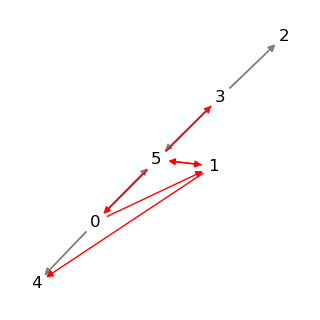

omitted edges (tensor([[5],
        [4]]), tensor([[2, 2, 2, 4, 4],
        [3, 4, 5, 0, 3]]))
omitted non edges tensor([[0, 0, 3, 3, 5, 5, 2, 2, 2, 4, 4, 1, 0, 0, 1, 3, 5],
        [5, 4, 2, 5, 2, 4, 3, 4, 5, 0, 3, 5, 1, 3, 4, 0, 1]])
new_edge_index tensor([[0, 0, 3, 3, 5, 5, 2, 2, 2, 4, 4, 1, 0, 0, 1, 3, 5],
        [5, 4, 2, 5, 2, 4, 3, 4, 5, 0, 3, 5, 1, 3, 4, 0, 1]])
new_edge_attr tensor([ True,  True,  True,  True,  True, False, False, False, False, False,
        False, False, False, False, False, False, False])


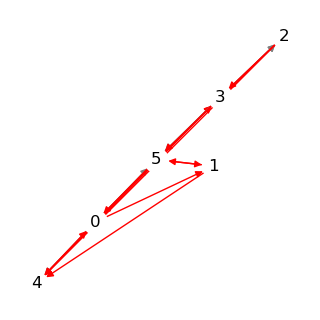

In [53]:
data = Data(edge_index=torch.tensor([[0, 0, 1, 3, 3, 5, 5],
                                     [5, 4, 5, 2, 5, 2, 4]]))

data.edge_attr = torch.tensor([1,1,1,1,1, 1,1]).bool()

#? TEST that dyad omittion makes sense for all attrs 1 (when omitting test)
test_p = 0.2
val_p = 0.2

#todo: test both get dyads to omit and omit dyads. 
dyads_to_omit_test = lp.omit_dyads_random(data.edge_index, 
                                data.edge_attr, 
                                p_sample_edge=test_p,
                                directed=True)
data_omitted1 = Data(edge_index=dyads_to_omit_test[1], edge_attr=dyads_to_omit_test[2])

# plot_directed_graph(data_omitted1)

print('omitted edges (B)', dyads_to_omit_test[0][0])
print('omitted non edges (C)', dyads_to_omit_test[0][1])
print('new_edge_index', data_omitted1.edge_index)
print('new_edge_attr', data_omitted1.edge_attr)

pos = plot_graph_with_omitted(data)
plot_graph_with_omitted(data_omitted1, pos)


#? TESTED that dyads omittiion makes sense for when the edge index has omitted dyads.
dyads_to_omit_val = lp.omit_dyads_random(data_omitted1.edge_index, data_omitted1.edge_attr, p_sample_edge=val_p/(1-test_p), directed=True)
data_omitted2 = Data(edge_index=dyads_to_omit_val[1], edge_attr=dyads_to_omit_val[2])

print('omitted edges', dyads_to_omit_val[0])
print('omitted non edges', dyads_to_omit_val[1])
print('new_edge_index', data_omitted2.edge_index)
print('new_edge_attr', data_omitted2.edge_attr)

plot_graph_with_omitted(data_omitted2, pos)
#? TEST


# Calculation



/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../datasets/import_dataset.py:247:::  
end of import_dataset
SmallDirected 
has 5 nodes 
and 13 edges. 
Graph is directed
Graph has self loops


Data(edge_index=[2, 13], edge_attr=[13], num_nodes=5, gt_nomalous=[5], name='SmallDirected')

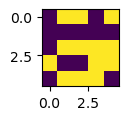

In [65]:
from datasets.import_dataset import import_dataset
import_dataset('SmallDirected', verbose=True)



/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../datasets/import_dataset.py:247:::  
end of import_dataset
SmallDirected 
has 5 nodes 
and 10 edges. 
Graph is directed
Graph has self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../trainer_directed.py:158:::  

Using dataset specific configuration and not global 






/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../datasets/import_dataset.py:247:::  
end of import_dataset
SmallDirected 
has 9 nodes 
and 22 edges. 
Graph is directed
Graph has self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../trainer_directed.py:158:::  

Using dataset specific configuration and not global 


omitted edges containes_self_loopsFalse
omitted non edges containes_self_loopsTrue


AttributeError: 'tuple' object has no attribute 'detach'

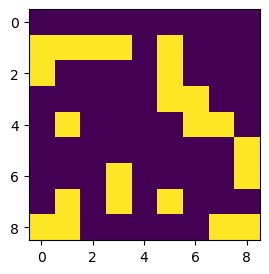

In [19]:

config_triplets = [['clamiter_init', 'dim_feat', 4]]
trainer_clam = Trainer(
                    dataset_name='SmallDirected', 
                    model_name='ieclam', device='cpu',
                    config_triplets_to_change=config_triplets)

edge_index = trainer_clam.data.edge_index
num_nodes = trainer_clam.data.num_nodes
num_edges = edge_index.shape[1]
num_neg_samples = num_nodes*num_nodes - num_edges

dyads_to_omit = lp.omit_dyads_random(edge_index, p_sample_edge=0.3, directed=True, edge_attr=torch.ones(num_edges).bool())

print(f'omitted edges containes_self_loops{upyg.contains_self_loops(dyads_to_omit[0][0])}')
print(f'omitted non edges containes_self_loops{upyg.contains_self_loops(dyads_to_omit[0][1])}')
non_adj = 1 - upyg.to_dense_adj(edge_index)[0]
non_edge_index = torch.stack(torch.where(non_adj == 1))

edge_index_retained = dyads_to_omit[1][:, dyads_to_omit[2]]

#non_edge_index retained
omitted_non_edges_adj = upyg.to_dense_adj(dyads_to_omit[0][1], max_num_nodes=num_nodes)[0]
non_edge_index_retained_mat = non_adj - omitted_non_edges_adj
non_edge_index_retained = torch.stack(torch.where(non_edge_index_retained_mat == 1))


plot_sparse_adj(edge_index, ((dyads_to_omit[0], None)))

#! how to get the non_edge_index that was retained?
grad_no_tricks = calc_grad_no_tricks(trainer_clam.data.x, edge_index_filtered, non_edge_index_filtered, lorenz=True)

In [ ]:
config_triplets = [['clamiter_init', 'dim_feat', 4]]
trainer_clam = Trainer(
                    dataset_name='SmallDirected', 
                    model_name='ieclam', device='cpu',
                    config_triplets_to_change=config_triplets)

edge_index = trainer_clam.data.edge_index
num_nodes = trainer_clam.data.num_nodes
num_edges = edge_index.shape[1]
num_neg_samples = num_nodes*num_nodes - num_edges

dyads_to_omit = lp.omit_dyads_random(edge_index, p_sample_edge=0.3, directed=True, edge_attr=torch.ones(num_edges).bool())

non_adj = 1 - upyg.to_dense_adj(edge_index)[0]
non_edge_index = torch.stack(torch.where(non_adj == 1))



# trainer_clam.create_clamiter(param_dictconfig_triplets = [['clamiter_init', 'dim_feat', 4]])
# trainer_clam.data.x = trainer_clam.clamiter.init_node_feats(num_nodes=trainer_clam.data.num_nodes, init_type='small_gaus')


# DEFINE THE EDGES TO OMIT
edge_index = trainer_clam.data.edge_index
num_nodes = trainer_clam.data.num_nodes
num_edges = edge_index.shape[1]
num_neg_samples = num_nodes*num_nodes - num_edges
dyads_to_omit = lp.omit_dyads_random(edge_index, p_sample_edge=0.3, directed=True, edge_attr=torch.ones(num_edges).bool())
# ==================================
#todo: make the calculation and anomaly detection experiments
#calculate with DIRECT SUMMATION and no trick
# these are the non edges, but there is probably a better way to get them


mask_edges_omitted = edge_mask_of_selected_edges(edge_index, dyads_to_omit[0])
mask_non_edges_omitted = edge_mask_of_selected_edges(non_edge_index, dyads_to_omit[1])

edge_index_filtered = edge_index[:, ~mask_edges_omitted]
non_edge_index_filtered = non_edge_index[:, ~mask_non_edges_omitted]
grad_no_tricks = calc_grad_no_tricks(trainer_clam.data.x, edge_index_filtered, non_edge_index_filtered, lorenz=True)
#======================================================

# SUMMATION TRICK in clamiter forward function
trainer_clam.data.edge_index, trainer_clam.data.edge_attr = trainer_clam.omit_dyads(dyads_to_omit)
node_mask = torch.ones(trainer_clam.data.x.shape[0], dtype=torch.bool)

grad_trainer = trainer_clam.clamiter.forward(trainer_clam.data, node_mask=node_mask)
# ======================================================

#? TEST direct summation == summation trick
assert torch.allclose(grad_no_tricks, 2*grad_trainer, atol=1e-4), f'''
the no tricks gradient is not the same as the gradient in trainer->clamiter->forward
grad_no_tricks: {grad_no_tricks}
2*grad_trainer: {2*grad_trainer}
grad_trainer: {grad_trainer}
'''
#? ==================================================
if verbose:
    printd('omitted the dyads and compared the gradient calculation with direct sum and the summation trick')
    #! notice that the edge_index is changed by the omit edges function!
    plot_adj(to_dense_adj(trainer_clam.data.edge_index_original)[0],dyads_to_omit)



/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../datasets/import_dataset.py:247:::  
end of import_dataset
SmallDirected 
has 5 nodes 
and 14 edges. 
Graph is directed
Graph has self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../trainer_directed.py:158:::  

Using dataset specific configuration and not global 




/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../datasets/import_dataset.py:247:::  
end of import_dataset
SmallDirected 
has 5 nodes 
and 11 edges. 
Graph is directed
Graph has self loops


/Users/danielzilberg/Documents/Learned_Graphon/ICML_PieClam_020425/tests/../trainer_directed.py:158:::  

Using dataset specific configuration and not global 




AttributeError: 'tuple' object has no attribute 'unsqueeze'

# Undirected

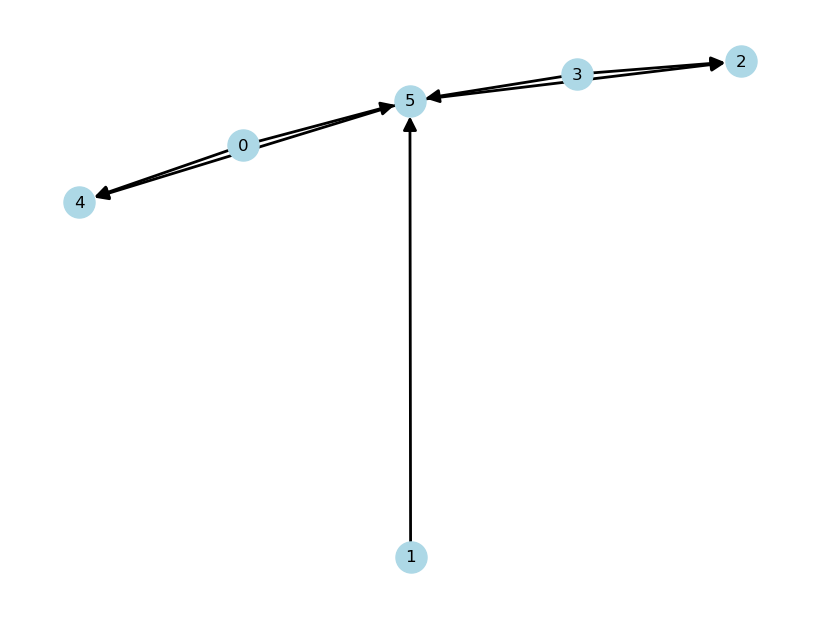

IndexError: tuple index out of range

In [ ]:
data = Data(edge_index=torch.tensor([[0, 0, 1, 3, 3, 5, 5],
                                     [5, 4, 5, 2, 5, 2, 4]]))

data.edge_attr = torch.tensor([1,1,1,1,1, 1,1]).bool()
plot_directed_graph(data)
data.edge_index, data.edge_attr = utils.to_undirected(data.edge_index, data.edge_attr)

#? TEST that dyad omittion makes sense for all attrs 1 (when omitting test)


#todo: make omit_dyads_random handle sampling rate of 0
dyads_to_omit_test = lp.omit_dyads_random(data.edge_index, 
                                data.edge_attr, 
                                p_sample_edge=0.0,
                                directed=False)
data_omitted1 = Data(edge_index=dyads_to_omit_test[2], edge_attr=dyads_to_omit_test[3])

# plot_directed_graph(data_omitted1)

print('omitted edges', dyads_to_omit_test[0])
print('omitted non edges', dyads_to_omit_test[1])
print('new_edge_index', data_omitted1.edge_index)
print('new_edge_attr', data_omitted1.edge_attr)

pos = plot_graph_with_omitted(data)
plot_graph_with_omitted(data_omitted1, pos)

#? TESTED that dyads omittiion makes sense for when the edge index has omitted dyads.
dyads_to_omit_val = lp.omit_dyads_random(data_omitted1.edge_index, data_omitted1.edge_attr, p_sample_edge=0.0)
data_omitted2 = Data(edge_index=dyads_to_omit_val[2], edge_attr=dyads_to_omit_val[3])

print('omitted edges', dyads_to_omit_val[0])
print('omitted non edges', dyads_to_omit_val[1])
print('new_edge_index', data_omitted2.edge_index)
print('new_edge_attr', data_omitted2.edge_attr)

plot_graph_with_omitted(data_omitted2, pos)
#? TEST
